# TextAwareGraphSAGE Document Classification on RVL-CDIP

This notebook implements the text-aware hybrid CNN+GNN fusion approach:
- **CNN path**: ResNet-50 avgpool features (2048-dim global context)
- **GNN path**: GraphSAGE on 7x7 spatial feature maps with 2D positional encoding + doctr text density (2051-dim nodes)
- **Fusion**: Concatenation of GNN embedding (32-dim) + CNN global (2048-dim) → Linear(2080, 16)

**Inputs:** `cached_features/` (from baseline notebook Sections 7 + 7.1, includes layer4, avgpool, text_density), `checkpoints/resnet50_baseline_metrics.json`, `checkpoints/hybrid_graphsage_metrics.json`

**Outputs:** `checkpoints/text_aware_hybrid_best.pt`, `checkpoints/text_aware_hybrid_metrics.json`

---

## 1. Setup

In [2]:
# C1: Imports
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.loader import DataLoader as PyGDataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm import tqdm

from src.config import Config
from src.data import load_rvl_cdip, RVL_CDIP_LABELS
from src.features import load_cached_features
from src.graph import build_grid_edge_index, build_graph_dataset_text_aware
from src.model import TextAwareGraphSAGE

print(f"PyTorch: {torch.__version__}")
print(f"PyG: {torch_geometric.__version__}")

/Users/sagarpratapsingh/dev/sagerstack/deep-learning-doc-classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0
PyG: 2.7.0


In [3]:
# C2: Config, seed, dataset metadata
config = Config()
config.seed_everything()

CHECKPOINT_DIR = Path("../checkpoints")

# Load dataset metadata to populate RVL_CDIP_LABELS
_ = load_rvl_cdip(config)

print(f"\nLabels loaded: {len(RVL_CDIP_LABELS)} classes")
print(f"Device: {config.device}")

'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)' thrown while requesting HEAD https://huggingface.co/datasets/vaclavpechtor/rvl_cdip-small-200/resolve/dfecd585c9b5c8fe56e8d7809d5b3cf710668dff/rvl_cdip-small-200.py
Retrying in 1s [Retry 1/5].


Device: mps
Mode: sample
Sample size: 100
Loading sample dataset: vaclavpechtor/rvl_cdip-small-200...


Using the latest cached version of the dataset since vaclavpechtor/rvl_cdip-small-200 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at .hf_cache/vaclavpechtor___rvl_cdip-small-200/default/0.0.0/dfecd585c9b5c8fe56e8d7809d5b3cf710668dff (last modified on Wed Mar 25 21:56:37 2026).


Loaded train: 2560 samples
Loaded validation: 640 samples

Labels loaded: 16 classes
Device: mps


## 2. Load Cached Features

Load the pre-extracted ResNet-50 features from the baseline notebook. Each cached file must contain:
- **features** [2048, 7, 7]: layer4 spatial features (used as graph nodes)
- **global_feat** [2048]: avgpool global features (used in fusion classifier)
- **text_density** [7, 7]: doctr DBNet text density heatmap
- **label**: document class

**Prerequisite:** Run baseline notebook Section 7.1 first to add `text_density` to cache.

In [4]:
# C3: Load cached features
cached_train = load_cached_features(config, "train")
cached_val = load_cached_features(config, "validation")

print(f"Train: {len(cached_train)} samples")
print(f"Val:   {len(cached_val)} samples")

# Verify text_density key exists
assert "text_density" in cached_train[0], \
    "Missing text_density in cache — run baseline notebook Section 7.1 first"
assert "text_density" in cached_val[0], \
    "Missing text_density in validation cache — run baseline notebook Section 7.1 first"

print(f"\nSample structure:")
print(f"  features:     {cached_train[0]['features'].shape}")
print(f"  global_feat:  {cached_train[0]['global_feat'].shape}")
print(f"  text_density: {cached_train[0]['text_density'].shape}")
print(f"  label:        {cached_train[0]['label']} ({RVL_CDIP_LABELS[cached_train[0]['label']]})")

print(f"\nText density range: [{cached_train[0]['text_density'].min():.4f}, {cached_train[0]['text_density'].max():.4f}]")

Loaded 2560 cached features from cached_features/train
Loaded 640 cached features from cached_features/validation
Train: 2560 samples
Val:   640 samples

Sample structure:
  features:     torch.Size([2048, 7, 7])
  global_feat:  torch.Size([2048])
  text_density: torch.Size([7, 7])
  label:        0 (advertisement)

Text density range: [0.0003, 0.2034]


## 3. Graph Construction with Text Density

Convert each feature map to a text-aware graph with:
- **49 nodes** (7x7 grid) with **2051-dim** features:
  - 2048 CNN channels (ResNet-50 layer4)
  - 2 normalized position coords (row, col in [0,1])
  - 1 text density scalar (doctr DBNet probability)
- **k=8 edges** (Moore neighborhood)
- **global_feat** stored as custom attribute [1, 2048] for correct PyG batching

In [5]:
# C4: Build text-aware graph datasets
GRID_H, GRID_W = 7, 7
K_NEIGHBORS = 8

edge_index = build_grid_edge_index(GRID_H, GRID_W, k=K_NEIGHBORS)
print(f"Grid: {GRID_H}x{GRID_W} = {GRID_H * GRID_W} nodes")
print(f"k={K_NEIGHBORS} (Moore neighborhood), {edge_index.shape[1]} directed edges")

train_graphs = build_graph_dataset_text_aware(cached_train, edge_index)
val_graphs = build_graph_dataset_text_aware(cached_val, edge_index)
print(f"\nTrain graphs: {len(train_graphs)}")
print(f"Val graphs:   {len(val_graphs)}")

Grid: 7x7 = 49 nodes
k=8 (Moore neighborhood), 312 directed edges

Train graphs: 2560
Val graphs:   640


In [6]:
# C5: Inspect graph structure and verify text density channel
g = train_graphs[0]
print(f"Node features: {g.x.shape}")
print(f"Edge index:    {g.edge_index.shape}")
print(f"Label:         {g.y.item()} ({RVL_CDIP_LABELS[g.y.item()]})")
print(f"Global feat:   {g.global_feat.shape}")

# Verify node dim is 2051
assert g.x.shape == (49, 2051), f"Expected [49, 2051] node features, got {g.x.shape}"
print(f"\nNode dim verified: 2051 (2048 CNN + 2 PE + 1 text_density)")

# Text density channel is the last feature
td_channel = g.x[:, -1]  # [49]
print(f"Text density range in sample: [{td_channel.min():.4f}, {td_channel.max():.4f}]")

print(f"\nPositional encoding (second-to-last 2 features):")
print(f"  Node 0  (row=0, col=0): PE = {g.x[0, -3:-1].tolist()}")
print(f"  Node 48 (row=6, col=6): PE = {g.x[48, -3:-1].tolist()}")

Node features: torch.Size([49, 2051])
Edge index:    torch.Size([2, 312])
Label:         0 (advertisement)
Global feat:   torch.Size([1, 2048])

Node dim verified: 2051 (2048 CNN + 2 PE + 1 text_density)
Text density range in sample: [0.0003, 0.2034]

Positional encoding (second-to-last 2 features):
  Node 0  (row=0, col=0): PE = [0.0, 0.0]
  Node 48 (row=6, col=6): PE = [1.0, 1.0]


## 4. DataLoader Setup

In [7]:
# C6: DataLoaders and batch verification
text_aware_train_loader = PyGDataLoader(train_graphs, batch_size=config.batch_size, shuffle=True)
text_aware_val_loader = PyGDataLoader(val_graphs, batch_size=config.batch_size, shuffle=False)

print(f"Train: {len(text_aware_train_loader)} batches")
print(f"Val:   {len(text_aware_val_loader)} batches")

batch = next(iter(text_aware_train_loader))
print(f"\nBatch structure:")
print(f"  x:           {batch.x.shape}")
print(f"  edge_index:  {batch.edge_index.shape}")
print(f"  y:           {batch.y.shape}")
print(f"  batch:       {batch.batch.shape} ({batch.batch.max().item() + 1} graphs)")
print(f"  global_feat: {batch.global_feat.shape}")

Train: 80 batches
Val:   20 batches

Batch structure:
  x:           torch.Size([1568, 2051])
  edge_index:  torch.Size([2, 9984])
  y:           torch.Size([32])
  batch:       torch.Size([1568]) (32 graphs)
  global_feat: torch.Size([32, 2048])


## 5. TextAwareGraphSAGE Model

Architecture with CNN+GNN fusion and text density:

```
GNN path:  SAGEConv(2051, 64) -> ReLU -> Dropout(0.7) -> SAGEConv(64, 32) -> ReLU -> global_mean_pool -> BN -> [B, 32]
CNN path:  avgpool features -> BN -> [B, 2048]
Fusion:    concat([32] + [2048]) -> Linear(2080, 16) -> logits
```

Node dim 2051 = 2048 CNN features + 2 PE coords + 1 text density scalar.

In [8]:
# C7: Instantiate model
text_aware_model = TextAwareGraphSAGE(
    node_dim=2051,
    hidden_channels=64,
    embed_channels=32,
    global_channels=2048,
    num_classes=len(RVL_CDIP_LABELS),
    dropout=0.7,
).to(config.device)

total_params = sum(p.numel() for p in text_aware_model.parameters())
trainable_params = sum(p.numel() for p in text_aware_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(text_aware_model)

Total parameters:     304,176
Trainable parameters: 304,176
TextAwareGraphSAGE(
  (conv1): SAGEConv(2051, 64, aggr=mean)
  (conv2): SAGEConv(64, 32, aggr=mean)
  (dropout): Dropout(p=0.7, inplace=False)
  (relu): ReLU()
  (gnn_bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (cnn_bn): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Linear(in_features=2080, out_features=16, bias=True)
)


## 5.1 Training

Using Adam with weight_decay=1e-4 and label smoothing (0.1) for regularization on small dataset. Early stopping with patience=15, minimum 20 epochs.

Same hyperparameters as Phase 2.1 HybridGraphSAGE for fair comparison.

In [9]:
# C8: Training config
NUM_EPOCHS = 100
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 15
MIN_EPOCHS = 20

optimizer = torch.optim.Adam(
    text_aware_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f"Epochs: {NUM_EPOCHS}")
print(f"Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Loss: CrossEntropy with label_smoothing=0.1")
print(f"Early stopping patience: {PATIENCE} (after epoch {MIN_EPOCHS})")

Epochs: 100
Optimizer: Adam (lr=0.0005, weight_decay=0.0001)
Loss: CrossEntropy with label_smoothing=0.1
Early stopping patience: 15 (after epoch 20)


In [10]:
# C9: Training loop
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
patience_counter = 0
best_checkpoint_path = CHECKPOINT_DIR / "text_aware_hybrid_best.pt"

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    text_aware_model.train()
    train_loss_sum, train_correct, train_total = 0.0, 0, 0

    for batch in text_aware_train_loader:
        batch = batch.to(config.device)
        optimizer.zero_grad()
        logits = text_aware_model(batch.x, batch.edge_index, batch.batch, batch.global_feat)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * batch.y.size(0)
        train_correct += (logits.argmax(dim=1) == batch.y).sum().item()
        train_total += batch.y.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # --- Validate ---
    text_aware_model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for batch in text_aware_val_loader:
            batch = batch.to(config.device)
            logits = text_aware_model(batch.x, batch.edge_index, batch.batch, batch.global_feat)
            loss = criterion(logits, batch.y)

            val_loss_sum += loss.item() * batch.y.size(0)
            val_correct += (logits.argmax(dim=1) == batch.y).sum().item()
            val_total += batch.y.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(text_aware_model.state_dict(), best_checkpoint_path)
        marker = " *"
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{marker}"
        )

    if patience_counter >= PATIENCE and (epoch + 1) >= MIN_EPOCHS:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print(f"Checkpoint: {best_checkpoint_path}")

Epoch 01/100 | Train Loss: 1.0849  Acc: 0.8473 | Val Loss: 1.7626  Acc: 0.5953 *
Epoch 05/100 | Train Loss: 0.6662  Acc: 0.9984 | Val Loss: 1.7242  Acc: 0.5766
Epoch 10/100 | Train Loss: 0.6268  Acc: 1.0000 | Val Loss: 1.7003  Acc: 0.5875
Epoch 15/100 | Train Loss: 0.6115  Acc: 1.0000 | Val Loss: 1.7016  Acc: 0.5906
Epoch 20/100 | Train Loss: 0.6023  Acc: 1.0000 | Val Loss: 1.6791  Acc: 0.5875
Epoch 25/100 | Train Loss: 0.6008  Acc: 1.0000 | Val Loss: 1.6666  Acc: 0.5938
Epoch 30/100 | Train Loss: 0.5979  Acc: 1.0000 | Val Loss: 1.6749  Acc: 0.5859

Early stopping at epoch 32

Best validation accuracy: 0.6000
Checkpoint: ../checkpoints/text_aware_hybrid_best.pt


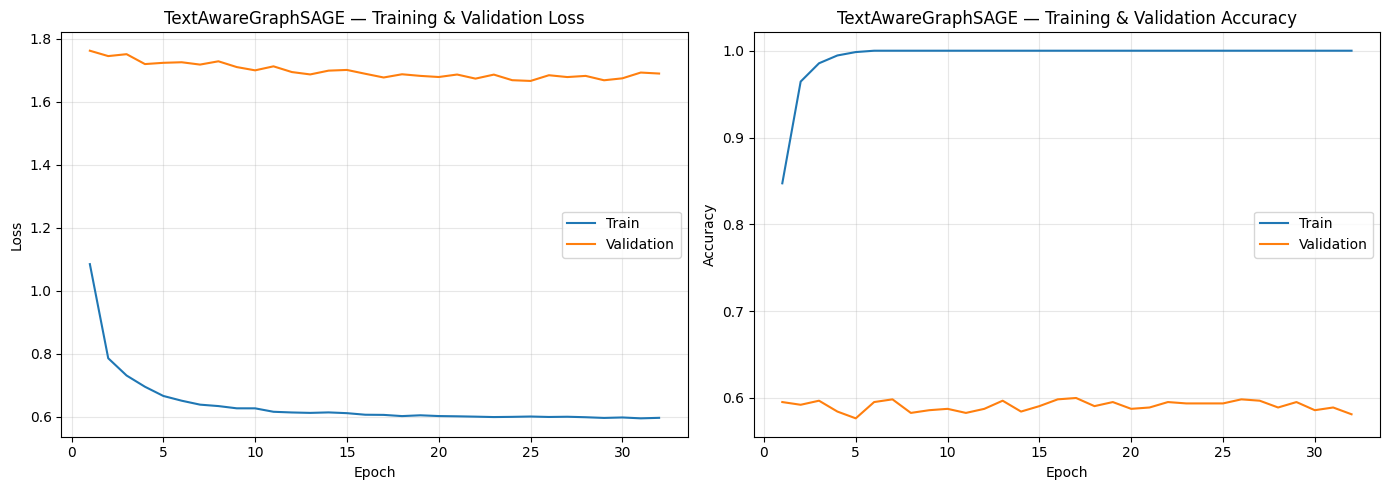

In [11]:
# C10: Training curves
epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('TextAwareGraphSAGE — Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='Train')
ax2.plot(epochs_range, history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('TextAwareGraphSAGE — Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

In [12]:
# C11: Load best model and collect predictions
text_aware_model.load_state_dict(torch.load(best_checkpoint_path, weights_only=True))
text_aware_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in text_aware_val_loader:
        batch = batch.to(config.device)
        logits = text_aware_model(batch.x, batch.edge_index, batch.batch, batch.global_feat)
        preds = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(batch.y.cpu().tolist())

text_aware_accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"TextAwareGraphSAGE validation accuracy: {text_aware_accuracy:.4f}")

TextAwareGraphSAGE validation accuracy: 0.6000


In [13]:
# C12: Classification report
report = classification_report(
    all_labels,
    all_preds,
    target_names=RVL_CDIP_LABELS,
    digits=4,
)
print(report)

                        precision    recall  f1-score   support

         advertisement     0.7381    0.7750    0.7561        40
                budget     0.4773    0.5250    0.5000        40
                 email     0.8205    0.8000    0.8101        40
           file_folder     0.7660    0.9000    0.8276        40
                  form     0.4167    0.3750    0.3947        40
           handwritten     0.8205    0.8000    0.8101        40
               invoice     0.4667    0.5250    0.4941        40
                letter     0.5000    0.5750    0.5349        40
                  memo     0.5172    0.3750    0.4348        40
          news_article     0.7188    0.5750    0.6389        40
          presentation     0.5278    0.4750    0.5000        40
         questionnaire     0.5667    0.4250    0.4857        40
                resume     0.6667    0.9500    0.7835        40
scientific_publication     0.6757    0.6250    0.6494        40
     scientific_report     0.2821    0.

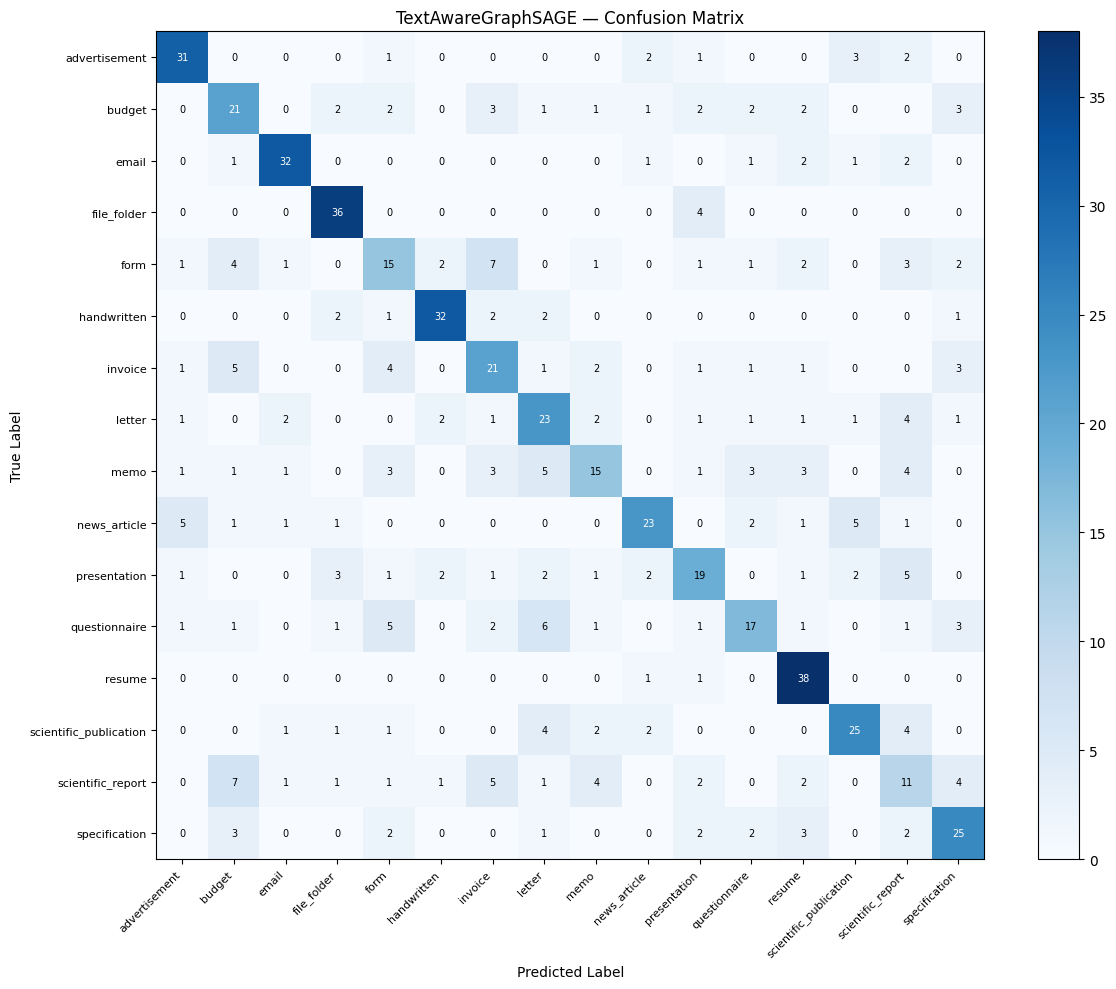

In [14]:
# C13: Confusion matrix heatmap
text_aware_cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(text_aware_cm, interpolation='nearest', cmap='Blues')
ax.set_title('TextAwareGraphSAGE — Confusion Matrix')
plt.colorbar(im, ax=ax, fraction=0.046)

tick_marks = np.arange(len(RVL_CDIP_LABELS))
ax.set_xticks(tick_marks)
ax.set_xticklabels(RVL_CDIP_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(tick_marks)
ax.set_yticklabels(RVL_CDIP_LABELS, fontsize=8)

thresh = text_aware_cm.max() / 2.0
for i in range(text_aware_cm.shape[0]):
    for j in range(text_aware_cm.shape[1]):
        ax.text(
            j, i, str(text_aware_cm[i, j]),
            ha='center', va='center',
            color='white' if text_aware_cm[i, j] > thresh else 'black',
            fontsize=7,
        )

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [15]:
# C14: Save text-aware hybrid metrics
text_aware_report_dict = classification_report(
    all_labels, all_preds, target_names=RVL_CDIP_LABELS, output_dict=True
)
text_aware_macro_f1 = f1_score(all_labels, all_preds, average='macro')

text_aware_metrics = {
    "model": "text_aware_hybrid",
    "accuracy": text_aware_accuracy,
    "per_class": {
        label: {
            "precision": text_aware_report_dict[label]["precision"],
            "recall": text_aware_report_dict[label]["recall"],
            "f1": text_aware_report_dict[label]["f1-score"],
            "support": text_aware_report_dict[label]["support"],
        }
        for label in RVL_CDIP_LABELS
    },
    "macro_avg": {
        "precision": text_aware_report_dict["macro avg"]["precision"],
        "recall": text_aware_report_dict["macro avg"]["recall"],
        "f1": text_aware_report_dict["macro avg"]["f1-score"],
    },
    "confusion_matrix": text_aware_cm.tolist(),
    "history": history,
    "architecture": {
        "node_dim": 2051,
        "hidden_channels": 64,
        "embed_channels": 32,
        "global_channels": 2048,
        "fusion_dim": 2080,
        "dropout": 0.7,
        "batch_norm": True,
        "label_smoothing": 0.1,
    },
    "graph_config": {
        "grid": f"{GRID_H}x{GRID_W}",
        "k_neighbors": K_NEIGHBORS,
        "positional_encoding": "2d_normalized",
        "text_density": "doctr_dbnet_7x7",
    },
}

text_aware_metrics_path = CHECKPOINT_DIR / "text_aware_hybrid_metrics.json"
with open(text_aware_metrics_path, 'w') as f:
    import json
    json.dump(text_aware_metrics, f, indent=2)

print(f"Metrics saved to: {text_aware_metrics_path}")
print(f"Accuracy: {text_aware_accuracy:.4f}")
print(f"Macro F1: {text_aware_macro_f1:.4f}")

Metrics saved to: ../checkpoints/text_aware_hybrid_metrics.json
Accuracy: 0.6000
Macro F1: 0.5943


## 7. Three-Way Comparison: Text-Aware vs Hybrid vs CNN Baseline

Compare TextAwareGraphSAGE against the Phase 2.1 HybridGraphSAGE and ResNet-50 CNN baseline to isolate the contribution of text density features.

**Focus classes:** form, invoice, memo, scientific_report — layout-sensitive classes expected to benefit most from text spatial structure.

In [16]:
# C15: Prerequisite check — verify upstream metrics files exist
from pathlib import Path

assert Path("../checkpoints/resnet50_baseline_metrics.json").exists(), \
    "Missing checkpoints/resnet50_baseline_metrics.json — run baseline notebook Section 8 first"
assert Path("../checkpoints/hybrid_graphsage_metrics.json").exists(), \
    "Missing checkpoints/hybrid_graphsage_metrics.json — run hybrid notebook Section 7 first"

print("All upstream metrics files found.")

All upstream metrics files found.


In [17]:
# C16: Load all model metrics
import json

baseline_metrics_path = CHECKPOINT_DIR / 'resnet50_baseline_metrics.json'
hybrid_metrics_path = CHECKPOINT_DIR / 'hybrid_graphsage_metrics.json'

with open(baseline_metrics_path) as f:
    baseline_metrics = json.load(f)
with open(hybrid_metrics_path) as f:
    hybrid_metrics = json.load(f)

# Summary comparison table
hybrid_macro_f1 = hybrid_metrics['macro_avg']['f1']

print(f"{'Model':<30} {'Val Acc':>10} {'Macro F1':>10}")
print('-' * 52)
print(f"{'CNN Baseline (ResNet-50)':<30} {baseline_metrics['accuracy']:>10.4f} {baseline_metrics['macro_avg']['f1']:>10.4f}")
print(f"{'HybridGraphSAGE (Phase 2.1)':<30} {hybrid_metrics['accuracy']:>10.4f} {hybrid_metrics['macro_avg']['f1']:>10.4f}")
print(f"{'TextAwareGraphSAGE':<30} {text_aware_accuracy:>10.4f} {text_aware_macro_f1:>10.4f}")

Model                             Val Acc   Macro F1
----------------------------------------------------
CNN Baseline (ResNet-50)           0.6359     0.6322
HybridGraphSAGE (Phase 2.1)        0.6141     0.6080
TextAwareGraphSAGE                 0.6000     0.5943


In [18]:
# C17: Per-class F1 breakdown with delta columns
LAYOUT_SENSITIVE = {'form', 'invoice', 'memo', 'scientific_report'}

print(f"{'Class':<25} {'Baseline F1':>12} {'Hybrid F1':>10} {'TextAware F1':>13} {'Delta (TA-H)':>12} Note")
print('-' * 85)

for label in RVL_CDIP_LABELS:
    b_f1 = baseline_metrics['per_class'][label]['f1']
    h_f1 = hybrid_metrics['per_class'][label]['f1']
    ta_f1 = text_aware_report_dict[label]['f1-score']
    delta_h = ta_f1 - h_f1
    note = '[layout-sensitive]' if label in LAYOUT_SENSITIVE else ''
    print(f"{label:<25} {b_f1:>12.4f} {h_f1:>10.4f} {ta_f1:>13.4f} {delta_h:>+12.4f}  {note}")

print('-' * 85)
b_macro = baseline_metrics['macro_avg']['f1']
print(f"{'Macro Average':<25} {b_macro:>12.4f} {hybrid_macro_f1:>10.4f} {text_aware_macro_f1:>13.4f} {text_aware_macro_f1 - hybrid_macro_f1:>+12.4f}")

Class                      Baseline F1  Hybrid F1  TextAware F1 Delta (TA-H) Note
-------------------------------------------------------------------------------------
advertisement                   0.7143     0.7059        0.7561      +0.0502  
budget                          0.5806     0.4835        0.5000      +0.0165  
email                           0.8095     0.7857        0.8101      +0.0244  
file_folder                     0.8395     0.8095        0.8276      +0.0181  
form                            0.4507     0.4286        0.3947      -0.0338  [layout-sensitive]
handwritten                     0.8049     0.7805        0.8101      +0.0296  
invoice                         0.5070     0.4932        0.4941      +0.0010  [layout-sensitive]
letter                          0.5814     0.5517        0.5349      -0.0168  
memo                            0.4935     0.5063        0.4348      -0.0715  [layout-sensitive]
news_article                    0.6571     0.6216        0.6389    

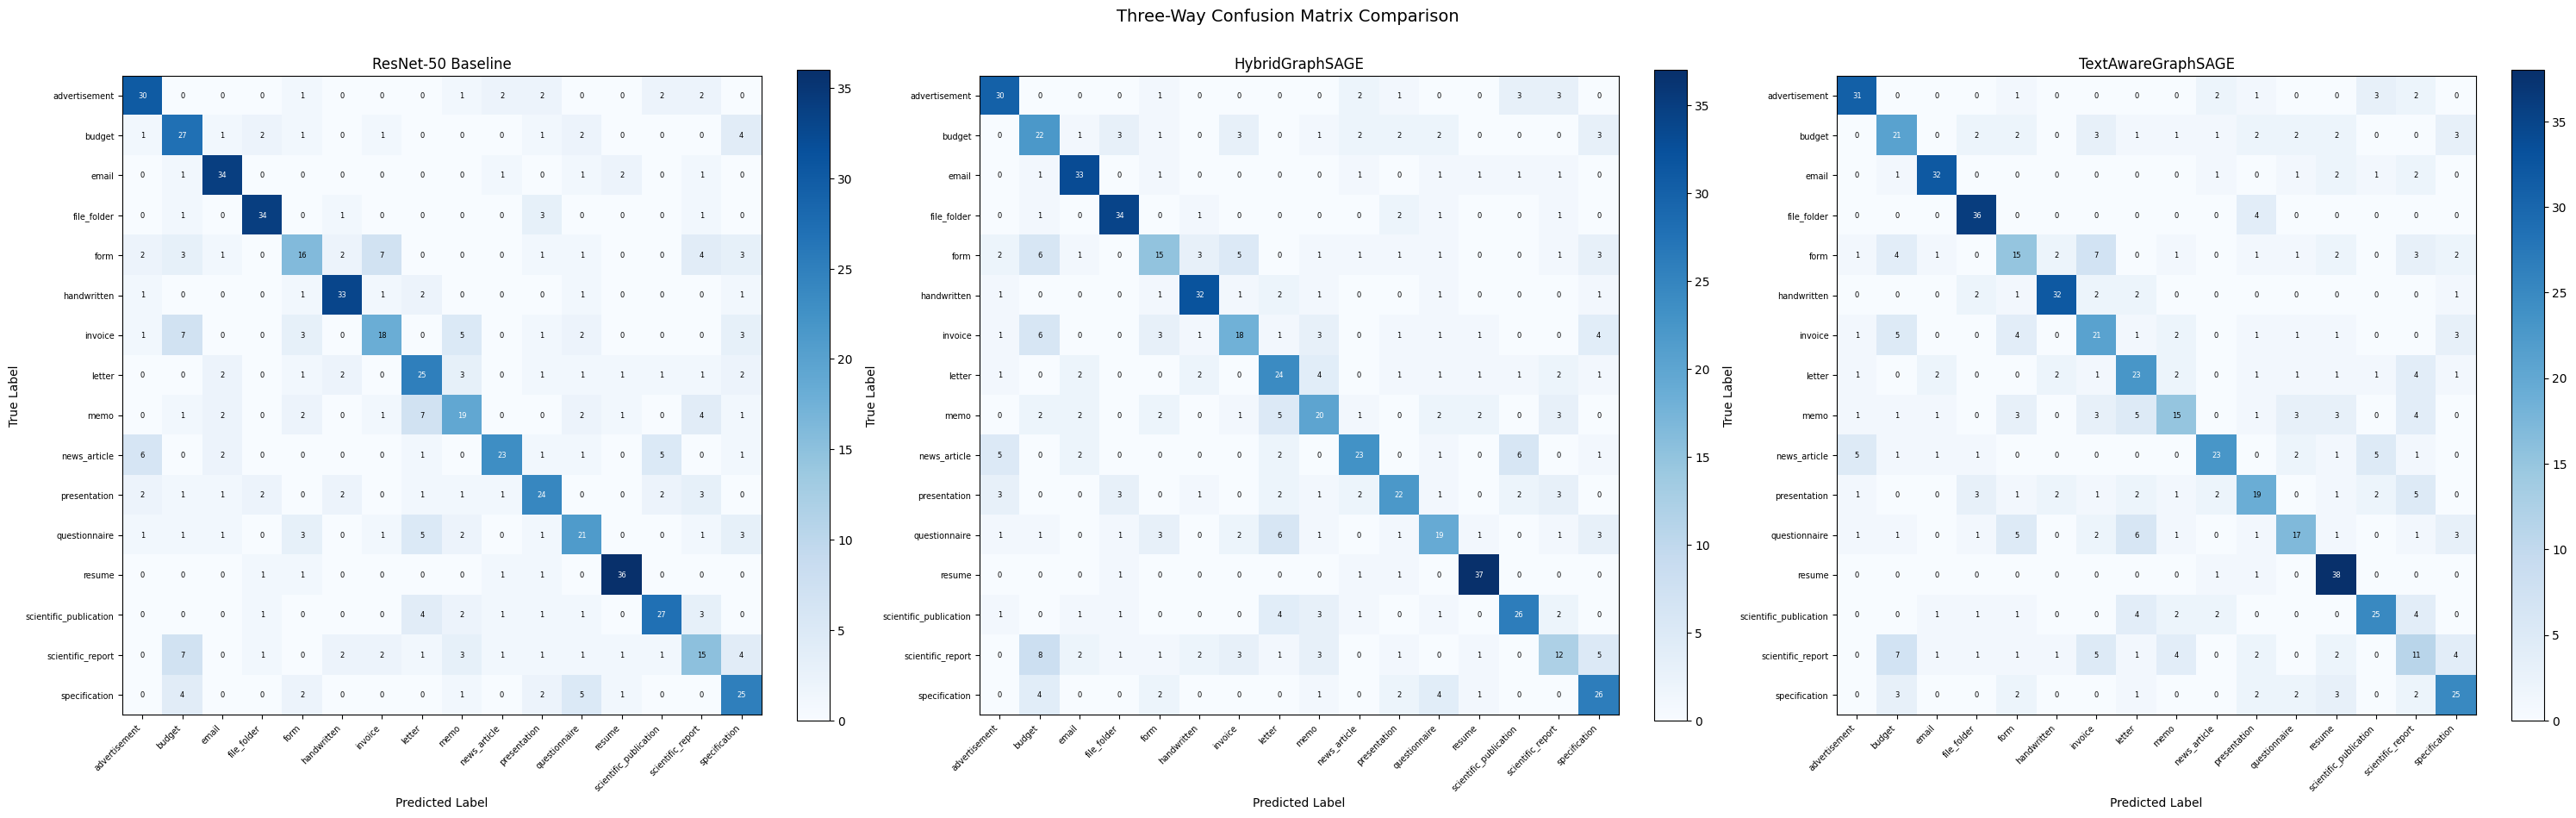

In [19]:
# C18: Triple confusion matrix comparison
baseline_cm = np.array(baseline_metrics['confusion_matrix'])
hybrid_cm = np.array(hybrid_metrics['confusion_matrix'])

fig, axes = plt.subplots(1, 3, figsize=(30, 9))

for ax, cm_data, title in [
    (axes[0], baseline_cm, 'ResNet-50 Baseline'),
    (axes[1], hybrid_cm, 'HybridGraphSAGE'),
    (axes[2], text_aware_cm, 'TextAwareGraphSAGE'),
]:
    im = ax.imshow(cm_data, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046)

    tick_marks = np.arange(len(RVL_CDIP_LABELS))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(RVL_CDIP_LABELS, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(RVL_CDIP_LABELS, fontsize=7)

    thresh = cm_data.max() / 2.0
    for i in range(cm_data.shape[0]):
        for j in range(cm_data.shape[1]):
            ax.text(
                j, i, str(cm_data[i, j]),
                ha='center', va='center',
                color='white' if cm_data[i, j] > thresh else 'black',
                fontsize=6,
            )

    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Three-Way Confusion Matrix Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7.1 Analysis

### What the per-class F1 table reveals

The `Delta (TA-H)` column shows the effect of adding text density over the plain hybrid approach:

- **Positive delta**: Text density helps (model learns that text-heavy vs sparse regions distinguish this class)
- **Negative delta**: Text density hurts or adds noise (possibly because the class boundary is visual, not text-based)

### Layout-sensitive class expectations

- **form**: Dense, uniform text blocks — text density should help delineate form fields
- **invoice**: Structured text regions (totals, line items) — spatial text patterns meaningful
- **memo**: Header-heavy text distribution — text density gradient top→body may differentiate
- **scientific_report**: Mixed text density (abstract dense, figures sparse)

### Notes on small-data training

With ~160 samples/class on the Small-200 subset, both hybrid and text-aware hybrid show strong train accuracy but limited validation improvement over CNN baseline. The GNN requires more data to learn meaningful spatial and text-spatial patterns. Full RVL-CDIP (320k) training is needed to realize the potential of text-aware features.